# Customer Churn Intelligence Platform

## Notebook 01: Data Understanding

---

### Objective

This notebook performs an initial assessment of the customer churn datasets used in the Customer Churn Intelligence Platform.

The primary objectives are:

- Load both datasets
- Understand dataset structure
- Identify feature types
- Analyze target variable distribution
- Detect missing values
- Detect duplicate records
- Compare the machine learning and business datasets
- Document initial observations before Exploratory Data Analysis (EDA)

---

### Datasets

**Dataset 1 (Machine Learning Dataset)**

- WA_Fn-UseC_-Telco-Customer-Churn.csv
- 21 features
- Used for ML model development

**Dataset 2 (Business Analytics Dataset)**

- Telco_customer_churn.xlsx
- 33 features
- Used for business insights and executive dashboards

---

### Expected Output

By the end of this notebook we will have:

- A complete understanding of both datasets
- A comparison between them
- Data quality assessment
- Initial observations for subsequent preprocessing and EDA

## Section 1: Import Libraries

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", "{:.2f}".format)

# Plot settings
plt.style.use("ggplot")
sns.set_theme(style="whitegrid")

print("All libraries imported successfully.")

All libraries imported successfully.


## Section 2: Project Configuration

In [2]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

print(f"Project Root: {PROJECT_ROOT}")

Project Root: d:\customer-churn-intelligence-platform


## Section 3: Import Project Modules

In [3]:
from src.config.paths import ML_DATASET_PATH, BUSINESS_DATASET_PATH, INTERIM_DATA_DIR
from src.config.settings import TARGET_COLUMN
from src.data.data_loader import load_all_datasets, save_dataset
from src.data.data_audit import (
    dataset_overview,
    missing_value_analysis,
    duplicate_analysis,
    feature_summary,
    target_summary,
    statistical_summary,
    unique_value_summary,
    data_quality_report
)
from src.data.dataset_compare import compare_datasets
from src.visualization.data_plots import (
    plot_missing_heatmap,
    plot_target_distribution,
    plot_target_pie
)
from src.utils.helpers import print_section

print("All project modules imported successfully.")

All project modules imported successfully.


## Section 4: Load Datasets

In [4]:
df_ml, df_business = load_all_datasets(ML_DATASET_PATH, BUSINESS_DATASET_PATH)

print("Datasets loaded successfully.")
print(f"\nMachine Learning Dataset Shape : {df_ml.shape}")
print(f"Business Dataset Shape         : {df_business.shape}")

Datasets loaded successfully.

Machine Learning Dataset Shape : (7043, 21)
Business Dataset Shape         : (7043, 33)


## Section 5: Sample Records

In [5]:
print_section("MACHINE LEARNING DATASET SAMPLE")
display(df_ml.head())

print("\n" + "="*70)
print_section("BUSINESS DATASET SAMPLE")
display(df_business.head())

MACHINE LEARNING DATASET SAMPLE


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes



BUSINESS DATASET SAMPLE


,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.96,-118.27,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.06,-118.31,Female,No,No,Yes,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.05,-118.29,Female,No,No,Yes,8,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.50,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.06,-118.32,Female,No,Yes,Yes,28,Yes,Yes,Fiber optic,No,No,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.04,-118.27,Male,No,No,Yes,49,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.30,Yes,1,89,5340,Competitor had better devices


## Section 6: Dataset Overview

In [6]:
# Machine Learning Dataset Overview
print_section("DATASET OVERVIEW - MACHINE LEARNING DATASET")
ml_overview = dataset_overview(df_ml)
display(ml_overview.metrics_df)
print("\nColumn Names:")
print(ml_overview.columns)
print("\nData Types:")
display(ml_overview.dtypes)

print("\n" + "="*70)

# Business Dataset Overview
print_section("DATASET OVERVIEW - BUSINESS DATASET")
biz_overview = dataset_overview(df_business)
display(biz_overview.metrics_df)
print("\nColumn Names:")
print(biz_overview.columns)
print("\nData Types:")
display(biz_overview.dtypes)

DATASET OVERVIEW - MACHINE LEARNING DATASET


,Metric,Value
0,Rows,7043
1,Columns,21
2,Categorical Features,18
3,Numerical Features,3
4,Memory Usage (KB),7975.07



Column Names:
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']

Data Types:


customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object


DATASET OVERVIEW - BUSINESS DATASET


,Metric,Value
0,Rows,7043
1,Columns,33
2,Categorical Features,24
3,Numerical Features,9
4,Memory Usage (KB),10752.11



Column Names:
['CustomerID', 'Count', 'Country', 'State', 'City', 'Zip Code', 'Lat Long', 'Latitude', 'Longitude', 'Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Tenure Months', 'Phone Service', 'Multiple Lines', 'Internet Service', 'Online Security', 'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method', 'Monthly Charges', 'Total Charges', 'Churn Label', 'Churn Value', 'Churn Score', 'CLTV', 'Churn Reason']

Data Types:


CustomerID            object
Count                  int64
Country               object
State                 object
City                  object
Zip Code               int64
Lat Long              object
Latitude             float64
Longitude            float64
Gender                object
Senior Citizen        object
Partner               object
Dependents            object
Tenure Months          int64
Phone Service         object
Multiple Lines        object
Internet Service      object
Online Security       object
Online Backup         object
Device Protection     object
Tech Support          object
Streaming TV          object
Streaming Movies      object
Contract              object
Paperless Billing     object
Payment Method        object
Monthly Charges      float64
Total Charges         object
Churn Label           object
Churn Value            int64
Churn Score            int64
CLTV                   int64
Churn Reason          object
dtype: object

## Section 7: Dataset Comparison

In [7]:
comp_report = compare_datasets(df_ml, df_business)

print_section("DATASET COMPARISON")
print(f"Common Columns        : {len(comp_report.common)}")
print(f"ML Dataset-only       : {len(comp_report.only_df1)}")
print(f"Business Dataset-only : {len(comp_report.only_df2)}")

print("\nCommon Columns:")
display(pd.DataFrame({"Common Columns": comp_report.common}))

if comp_report.only_df1:
    print("\nML-only Columns:")
    display(pd.DataFrame({"ML Only Columns": comp_report.only_df1}))

if comp_report.only_df2:
    print("\nBusiness-only Columns:")
    display(pd.DataFrame({"Business Only Columns": comp_report.only_df2}))

DATASET COMPARISON
Common Columns        : 3
ML Dataset-only       : 18
Business Dataset-only : 30

Common Columns:


,Common Columns
0,Contract
1,Dependents
2,Partner



ML-only Columns:


,ML Only Columns
0,Churn
1,DeviceProtection
2,InternetService
3,MonthlyCharges
4,MultipleLines
5,OnlineBackup
6,OnlineSecurity
7,PaperlessBilling
8,PaymentMethod
9,PhoneService



Business-only Columns:


,Business Only Columns
0,CLTV
1,Churn Label
2,Churn Reason
3,Churn Score
4,Churn Value
5,City
6,Count
7,Country
8,CustomerID
9,Device Protection


## Section 8: Statistical Summary

In [8]:
ml_stats = statistical_summary(df_ml)

print_section("NUMERICAL FEATURES SUMMARY - MACHINE LEARNING DATASET")
display(ml_stats.numerical)

print("\n" + "="*70)

print_section("CATEGORICAL FEATURES SUMMARY - MACHINE LEARNING DATASET")
display(ml_stats.categorical)

NUMERICAL FEATURES SUMMARY - MACHINE LEARNING DATASET


,SeniorCitizen,tenure,MonthlyCharges
count,7043.00,7043.00,7043.00
mean,0.16,32.37,64.76
std,0.37,24.56,30.09
min,0.00,0.00,18.25
25%,0.00,9.00,35.50
50%,0.00,29.00,70.35
75%,0.00,55.00,89.85
max,1.00,72.00,118.75



CATEGORICAL FEATURES SUMMARY - MACHINE LEARNING DATASET


,customerID,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,TotalCharges,Churn
count,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043
unique,7043,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4,6531,2
top,3186-AJIEK,Male,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,20.2,No
freq,1,3555,3641,4933,6361,3390,3096,3498,3088,3095,3473,2810,2785,3875,4171,2365,11,5174


## Section 9: Feature Summary

In [9]:
# Machine Learning Features
print_section("FEATURE SUMMARY - MACHINE LEARNING DATASET")
ml_features = feature_summary(df_ml)
display(ml_features.summary_df)
print("\nCategorical Features:")
print(ml_features.categorical_cols)
print("\nNumerical Features:")
print(ml_features.numerical_cols)

print("\n" + "="*70)

# Business Features
print_section("FEATURE SUMMARY - BUSINESS DATASET")
biz_features = feature_summary(df_business)
display(biz_features.summary_df)
print("\nCategorical Features:")
print(biz_features.categorical_cols)
print("\nNumerical Features:")
print(biz_features.numerical_cols)

FEATURE SUMMARY - MACHINE LEARNING DATASET


,Metric,Value
0,Total Features,21
1,Categorical,18
2,Numerical,3



Categorical Features:
['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'TotalCharges', 'Churn']

Numerical Features:
['SeniorCitizen', 'tenure', 'MonthlyCharges']

FEATURE SUMMARY - BUSINESS DATASET


,Metric,Value
0,Total Features,33
1,Categorical,24
2,Numerical,9



Categorical Features:
['CustomerID', 'Country', 'State', 'City', 'Lat Long', 'Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Phone Service', 'Multiple Lines', 'Internet Service', 'Online Security', 'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method', 'Total Charges', 'Churn Label', 'Churn Reason']

Numerical Features:
['Count', 'Zip Code', 'Latitude', 'Longitude', 'Tenure Months', 'Monthly Charges', 'Churn Value', 'Churn Score', 'CLTV']


## Section 10: Unique Values Analysis

In [10]:
print_section("UNIQUE VALUE SUMMARY - ML DATASET")
ml_uniques = unique_value_summary(df_ml)
display(ml_uniques)

UNIQUE VALUE SUMMARY - ML DATASET


,Data Type,Unique Values,Missing Values
customerID,object,7043,0
gender,object,2,0
SeniorCitizen,int64,2,0
Partner,object,2,0
Dependents,object,2,0
tenure,int64,73,0
PhoneService,object,2,0
MultipleLines,object,3,0
InternetService,object,3,0
OnlineSecurity,object,3,0


## Section 11: Missing Value Analysis

In [11]:
# Machine Learning Missing Values
print_section("MISSING VALUE ANALYSIS - MACHINE LEARNING DATASET")
ml_missing = missing_value_analysis(df_ml)
if ml_missing.empty:
    print("No missing values found.")
else:
    display(ml_missing)

print("\n" + "="*70)

# Business Missing Values
print_section("MISSING VALUE ANALYSIS - BUSINESS DATASET")
biz_missing = missing_value_analysis(df_business)
if biz_missing.empty:
    print("No missing values found.")
else:
    display(biz_missing)

MISSING VALUE ANALYSIS - MACHINE LEARNING DATASET
No missing values found.

MISSING VALUE ANALYSIS - BUSINESS DATASET


,Missing Values,Percentage (%)
Churn Reason,5174,73.46


### Missing Value Heatmaps

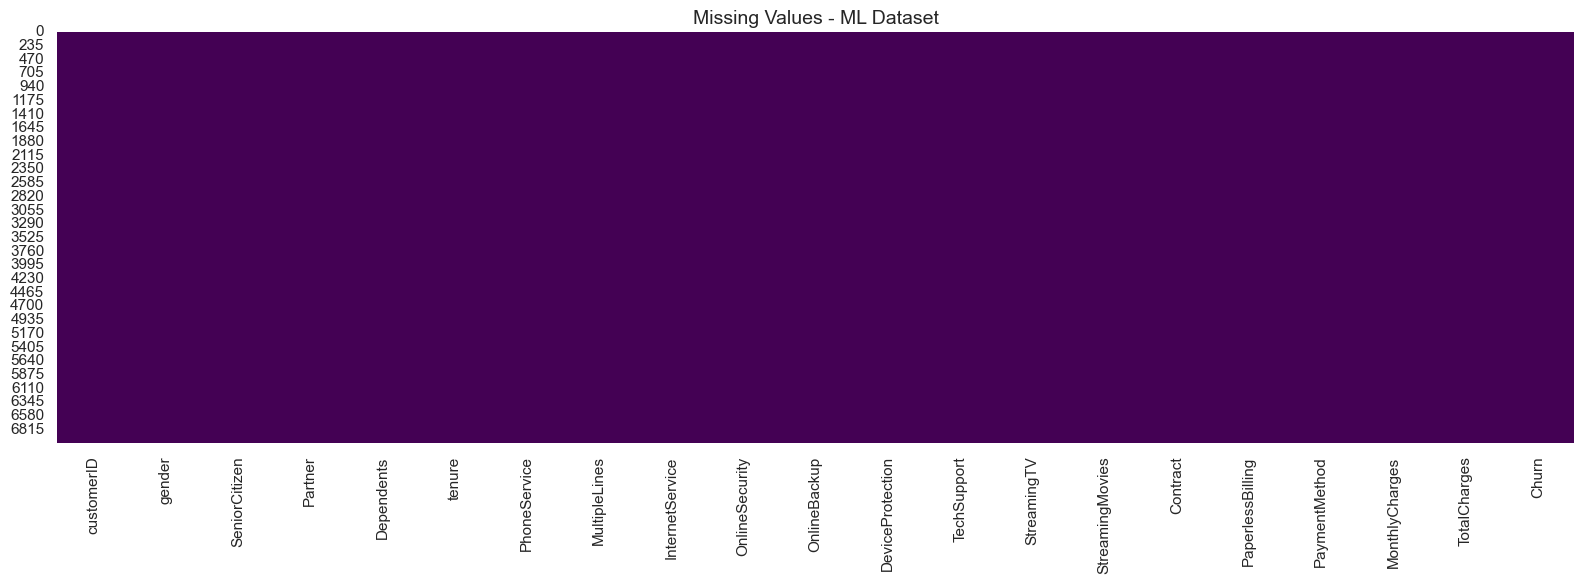

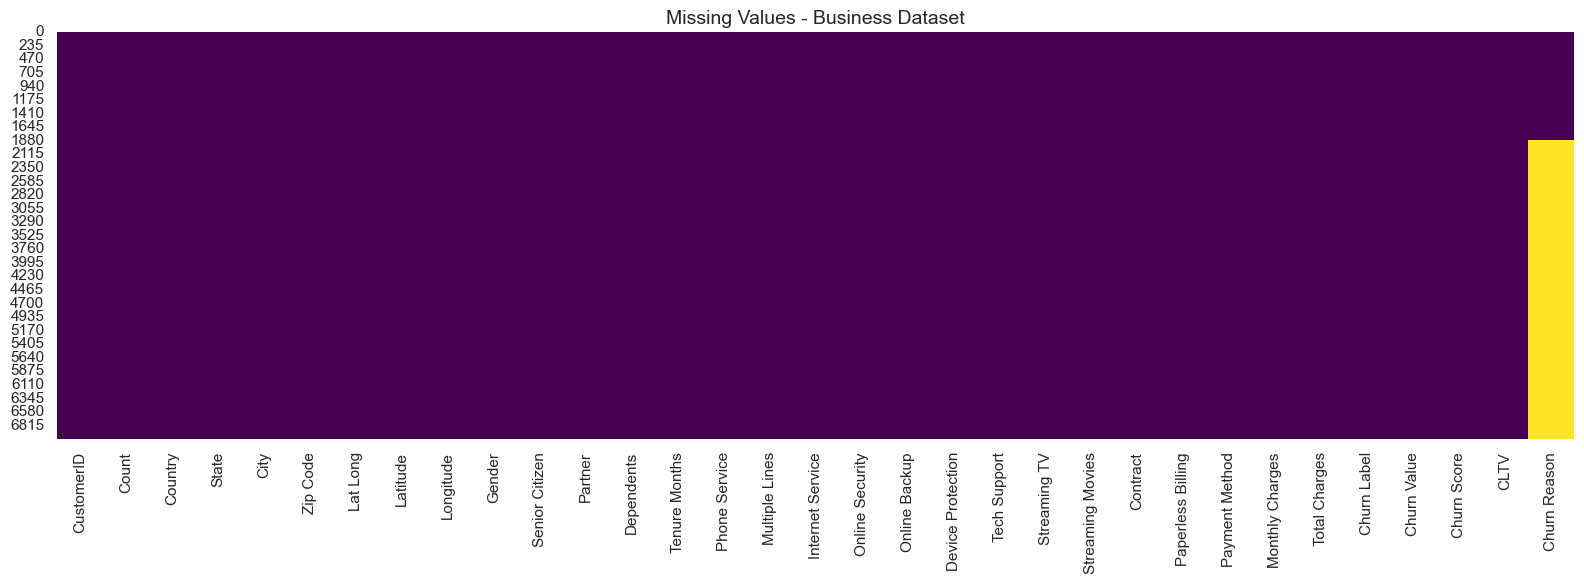

In [12]:
plot_missing_heatmap(df_ml, title="Missing Values - ML Dataset")
plot_missing_heatmap(df_business, title="Missing Values - Business Dataset")

## Section 12: Duplicate Record Analysis

In [13]:
# Machine Learning Duplicates
print_section("DUPLICATE RECORD ANALYSIS - ML DATASET")
ml_dups = duplicate_analysis(df_ml)
print(f"Duplicate Rows : {ml_dups.count}")
print(f"Percentage     : {ml_dups.percentage:.2f}%")

print("\n" + "="*70)

# Business Duplicates
print_section("DUPLICATE RECORD ANALYSIS - BUSINESS DATASET")
biz_dups = duplicate_analysis(df_business)
print(f"Duplicate Rows : {biz_dups.count}")
print(f"Percentage     : {biz_dups.percentage:.2f}%")

DUPLICATE RECORD ANALYSIS - ML DATASET
Duplicate Rows : 0
Percentage     : 0.00%

DUPLICATE RECORD ANALYSIS - BUSINESS DATASET
Duplicate Rows : 0
Percentage     : 0.00%


## Section 13: Target Variable Analysis

In [14]:
target_info = target_summary(df_ml, target_col=TARGET_COLUMN)

print_section("TARGET VARIABLE DISTRIBUTION")
target_df = pd.DataFrame({
    "Count": target_info.counts,
    "Percentage (%)": target_info.percentages
})
display(target_df)

print("\n" + "="*70)

print_section("CLASS IMBALANCE")
print(f"Majority Class  : {target_info.counts.max()}")
print(f"Minority Class  : {target_info.counts.min()}")
print(f"Imbalance Ratio : {target_info.imbalance_ratio}:1")
print(f"\nDataset Status  : {target_info.status}")

TARGET VARIABLE DISTRIBUTION


,Count,Percentage (%)
Churn,,
No,5174,73.46
Yes,1869,26.54



CLASS IMBALANCE
Majority Class  : 5174
Minority Class  : 1869
Imbalance Ratio : 2.77:1

Dataset Status  : Moderately Imbalanced


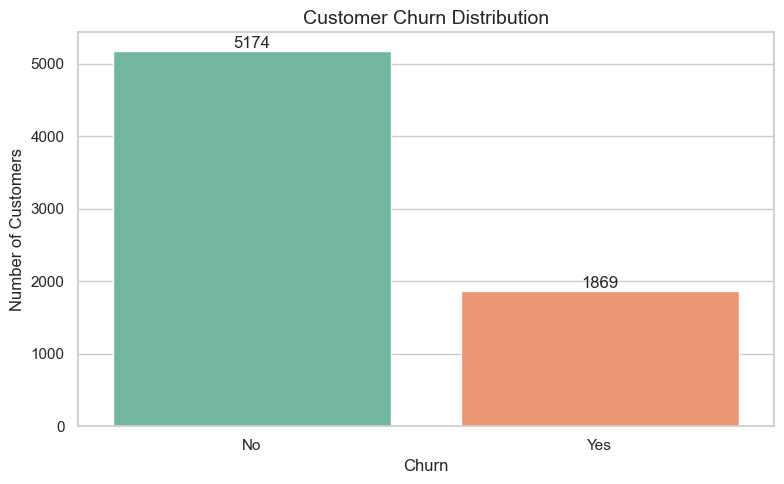

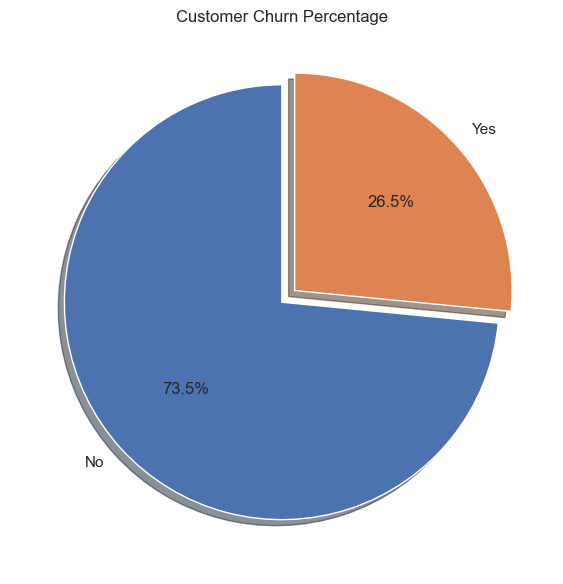

In [15]:
plot_target_distribution(df_ml, target_col=TARGET_COLUMN)
plot_target_pie(target_info.counts)

## Section 14: Data Quality Report

In [16]:
print_section("DATA QUALITY REPORT")
quality_rep = data_quality_report(df_ml, df_business)
display(quality_rep)

DATA QUALITY REPORT


,Metric,Value
0,ML Dataset Rows,7043
1,ML Dataset Columns,21
2,Business Dataset Rows,7043
3,Business Dataset Columns,33
4,Duplicate Rows (ML),0
5,Duplicate Rows (Business),0
6,Missing Values (ML),0
7,Missing Values (Business),5174


## Initial Observations

### Machine Learning Dataset

- Contains customer demographic, account, and service information.
- 21 columns — compact feature set suitable for ML modeling.
- No missing values detected in initial scan.
- No duplicate rows.
- Target variable **Churn** is binary (Yes/No).
- Moderate class imbalance → may require balancing strategies.

### Business Dataset

- Contains 33 columns with additional business metrics.
- Includes revenue, CLTV, and churn-related scores.
- Missing values present in some columns → will need imputation.
- No duplicate rows.

### Next Steps

- Proceed to **Notebook 02: Exploratory Data Analysis** for deeper feature-level analysis.
- Address missing values during preprocessing.
- Evaluate class imbalance strategies during modeling.

## Section 15: Save Interim Datasets

In [17]:
ml_output = INTERIM_DATA_DIR / "ml_dataset_interim.csv"
business_output = INTERIM_DATA_DIR / "business_dataset_interim.csv"

save_dataset(df_ml, ml_output)
save_dataset(df_business, business_output)

print_section("INTERIM DATASETS SAVED SUCCESSFULLY")
print(f"ML Dataset       : {ml_output}")
print(f"Business Dataset : {business_output}")

INTERIM DATASETS SAVED SUCCESSFULLY
ML Dataset       : D:\customer-churn-intelligence-platform\data\interim\ml_dataset_interim.csv
Business Dataset : D:\customer-churn-intelligence-platform\data\interim\business_dataset_interim.csv
